# APR Amazon 지수 — 체인 LFL 검증 V5

`apr_us_amazon_keepa_query_v5.ipynb`

---

## V4에서 드러난 문제

재보간은 성공했다(톱니 0.074 → 0.002). 그러나 그 덕분에 더 근본적인 결함이 보였다.

| 문제 | 증상 | 원인 |
|---|---|---|
| 점유율 지수 +7286% | 무의미한 숫자 | 누적곱이 초기 구간에 지배됨. 2023년 Amazon은 0에 가까웠고 수출은 이미 1,837억 |
| 균형패널 4개 | 판정 유보 | 1,311일 전체를 커버하는 ASIN은 가장 오래된 4개뿐. 하필 모멘텀이 식은 초기 제품 |
| Amazon 가속이 항상 음수 | 정보가 아닌 산술 | 기저가 커지며 YoY 비율이 기계적으로 감쇠 |
| 2026Q3 YoY −72% | 허수 | 7월 한 달을 분기 평균으로 계산 |

뿌리는 하나다. **지수 구성이 시간에 따라 20배 변했다** (ASIN 2개 → 48개).
구성이 변하는 지수의 YoY는 성장률이 아니라 구성 변화를 측정한다.

## V5의 해법 — 체인 연결 동일점포(LFL)

고정 바스켓을 버리고, **분기마다 비교 대상을 새로 잡는다.**

```
각 분기 q에 대해:
    공통 = (q에 유효한 ASIN) ∩ (q−4에 유효한 ASIN)
    LFL_YoY(q) = Σ gmv[q, 공통] / Σ gmv[q−4, 공통] − 1
```

소매업의 동일점포매출과 같은 방식이다. 바스켓을 길게 유지할 필요가 없으므로
**균형패널 4개 문제가 통째로 사라진다.**

덤으로 성장을 분해할 수 있다.

```
total_yoy   = 전체 ASIN 기준 (구성 변화 포함)
lfl_yoy     = 공통 ASIN 기준 (기존 SKU 자체 모멘텀)
sku_effect  = total − lfl  (신제품 기여)
```

## 그 외 수정

- **미완결 분기 제외** — 분기 일수 커버리지가 기준 미만이면 드롭 (2026Q3 허수 제거)
- **점유율 재설계** — 누적곱 폐기. 분기별 상대성장 `(1+LFL)/(1+수출)` 의 추세로 판단.
  **1.0 아래로 내려가면 (B) 채널 믹스 이동**
- **가속 크기 검증** — 부호만 세지 않는다. Amazon 가속이 수출의 15~40배면
  방향이 맞아도 일치로 세지 않는다
- **분석창 민감도** — 시작일을 바꿔가며 결과가 어떻게 변하는지 표로 제시.
  창 조정은 이 표를 보고 정한다

---
**V5** | 2026-08

## 1. 사용자 입력 변수

In [1]:
# ============================================================================
# USER INPUT
# ============================================================================

TICKER          = "A278470"
DOMAIN          = "US"

# ---------- 재보간 ----------
REFILL_ENABLED  = True
REFILL_LIMIT_D  = 21
REFILL_GRID     = [7, 14, 21, 30]

# ---------- 분석창 ----------
ANALYSIS_MIN_DATE = "2023-01-01"    # 결과를 보고 12장 민감도 표에서 조정
COVERAGE_ABS_MIN  = 3               # 머리 절단: 활성 ASIN 절대 하한
COVERAGE_MIN      = 0.70            # 꼬리 절단: 전체 최대 대비
WINDOW_GRID     = ["2023-01-01", "2023-07-01", "2024-01-01", "2024-07-01"]

# ---------- 분기 유효성 ----------
QUARTER_MIN_COVER = 0.80        # 분기 일수의 이 비율 미만이면 미완결로 제외
ASIN_Q_MIN_COVER  = 0.50        # ASIN이 해당 분기의 이 비율 이상 관측돼야 유효
MIN_COMMON_ASIN   = 5           # 공통 ASIN이 이보다 적으면 LFL 산출 불가

# ---------- 지수 ----------
ALPHA           = 0.70
ALPHA_GRID      = [0.5, 0.6, 0.7, 0.8, 0.9]

# ---------- 검증 ----------
LAG_RANGE       = [0, 1, 2]
MAGNITUDE_MAX   = 5.0           # 가속 크기 비율이 이보다 크면 '일치'로 세지 않음
MIN_ACC_OBS     = 5             # 가속 관측치 하한 (미달 시 판정 유보)
MIN_COMMON_MEAN = 8             # 평균 공통 ASIN 수 하한

# ---------- 관세청 (선택) ----------
CUSTOMS_ENABLED = False
CUSTOMS_SQL     = None
CUSTOMS_DATE_COL = "date"
CUSTOMS_VAL_COL  = "usd_amt"

# ---------- 시각화 ----------
SHOW_PLOTS      = True
FIG_W           = 14

# ---------- 테이블 ----------
TBL_ASIN_MASTER = "amazon_asin_master"
TBL_BSR_DAILY   = "amazon_bsr_daily"
TBL_APR_REV     = "apr_revenue_quarterly"


## 2. 환경 · DB

In [2]:
import os
import sys
import json
import warnings
from datetime import date, datetime
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2


In [3]:
from sqlalchemy import text

ENGINE, DB_AVAILABLE = None, False


def make_engine():
    errs = []
    for fn, desc in [
        (lambda: __import__("config").get_engine(__import__("config").get_db_info()),
         "config.get_engine(db_info)"),
        (lambda: __import__("config").get_engine(), "config.get_engine()"),
    ]:
        try:
            return fn(), desc
        except Exception as e:
            errs.append("%s: %s" % (desc, repr(e)[:90]))
    raise RuntimeError("DB 연결 실패 -> " + " | ".join(errs))


try:
    ENGINE, _how = make_engine()
    with ENGINE.connect() as _c:
        _db = _c.execute(text("SELECT DATABASE()")).scalar()
    DB_AVAILABLE = True
    print("[DB] 연결 성공 - %s / database=%s" % (_how, _db))
except Exception as e:
    print("[DB] 연결 실패:", repr(e)[:250])
    print("   config.py: %s (존재=%s)" % (os.path.join(BASE_PATH, "config.py"),
                                          os.path.exists(os.path.join(BASE_PATH, "config.py"))))


[DB] 연결 성공 - config.get_engine(db_info) / database=investar


## 3. 공시 앵커

새 보고서가 나오면 **누적값 한 줄만 추가**하면 된다.

In [4]:
# ============================================================================
# APR 뷰티 부문 — DART 공시 누적값 (백만원, 연결기준)
#   ※ 새 분기 보고서가 나오면 아래에 누적값 한 줄만 추가하십시오.
# ============================================================================

CUM_EXPORT = {
    "2024Q1":    62_117, "2024Q2":   134_430, "2024Q3":   234_023, "2024Q4":   389_939,
    "2025Q1":   189_274, "2025Q2":   443_795, "2025Q3":   753_700, "2025Q4": 1_225_736,
    "2026Q1":   528_064,
    # "2026Q2": ???,   ← 반기보고서. 이 한 줄이 (A)/(B)를 가른다.
}
CUM_DOMESTIC = {
    "2024Q1":  70_049, "2024Q2": 137_555, "2024Q3": 197_421, "2024Q4": 261_222,
    "2025Q1":  66_645, "2025Q2": 129_236, "2025Q3": 194_773, "2025Q4": 258_374,
    "2026Q1":  57_239,
}
ANCHOR_SOURCE = "DART 매출실적(뷰티, 연결기준) 누적 차분"


def cum_to_q(cum: Dict[str, int]) -> Tuple[Dict[str, float], List[str]]:
    out, warns = {}, []
    for q in sorted(cum):
        y, n = q[:4], int(q[-1])
        if n == 1:
            out[q] = float(cum[q]); continue
        prev = "%sQ%d" % (y, n - 1)
        if prev not in cum:
            warns.append("%s: 직전 누적 없음" % q); out[q] = np.nan; continue
        v = cum[q] - cum[prev]
        if v < 0:
            warns.append("%s: 차분 음수(%d) → 정정공시 의심" % (q, v)); out[q] = np.nan
        else:
            out[q] = float(v)
    return out, warns


qe, w1 = cum_to_q(CUM_EXPORT)
qd, w2 = cum_to_q(CUM_DOMESTIC)
for w in w1 + w2:
    print("[경고]", w)

rev = pd.DataFrame({"export": pd.Series(qe), "domestic": pd.Series(qd)}).sort_index()
rev.index.name = "yyyyq"
rev["total"] = rev["export"] + rev["domestic"]
rev["export_share"] = rev["export"] / rev["total"]
rev["export_yoy"] = rev["export"].pct_change(4)
rev["domestic_yoy"] = rev["domestic"].pct_change(4)
rev["period"] = pd.PeriodIndex(rev.index, freq="Q")

print("=" * 88)
print("공시 앵커 — 분기 매출 (백만원)")
print("=" * 88)
d_ = rev[["export", "domestic", "export_share", "export_yoy", "domestic_yoy"]].copy()
for c in ["export", "domestic"]:
    d_[c] = d_[c].map(lambda v: format(int(v), ",") if pd.notna(v) else "-")
for c in ["export_share", "export_yoy", "domestic_yoy"]:
    d_[c] = d_[c].map(lambda v: "%.1f%%" % (v * 100) if pd.notna(v) else "-")
print(d_.to_string())

print()
for y in sorted(set(i[:4] for i in rev.index)):
    qs = [i for i in rev.index if i.startswith(y)]
    if len(qs) < 4:
        print("  %s 미완결 (%d분기)" % (y, len(qs))); continue
    se = rev.loc[qs, "export"].sum()
    print("  %s 분기합 %13s  %s" % (y, format(int(se), ","),
          "OK" if abs(se - CUM_EXPORT["%sQ4" % y]) < 1 else "MISMATCH"))


공시 앵커 — 분기 매출 (백만원)
         export domestic export_share export_yoy domestic_yoy
yyyyq                                                        
2024Q1   62,117   70,049        47.0%          -            -
2024Q2   72,313   67,506        51.7%          -            -
2024Q3   99,593   59,866        62.5%          -            -
2024Q4  155,916   63,801        71.0%          -            -
2025Q1  189,274   66,645        74.0%     204.7%        -4.9%
2025Q2  254,521   62,591        80.3%     252.0%        -7.3%
2025Q3  309,905   65,537        82.5%     211.2%         9.5%
2025Q4  472,036   63,601        88.1%     202.8%        -0.3%
2026Q1  528,064   57,239        90.2%     179.0%       -14.1%

  2024 분기합       389,939  OK
  2025 분기합     1,225,736  OK
  2026 미완결 (1분기)


## 4. 로드 · 재보간

`is_ffilled=0` 인 실관측 시점에서 패널을 재구성한다. 재수집·토큰 불필요.

In [5]:
daily_raw = pd.DataFrame(); master = pd.DataFrame()

if DB_AVAILABLE:
    master = pd.read_sql(
        text("SELECT * FROM {t} WHERE ticker=:tk AND domain=:dm".format(t=TBL_ASIN_MASTER)),
        ENGINE, params={"tk": TICKER, "dm": DOMAIN})
    if len(master):
        al = master["asin"].tolist()
        ph = ",".join([":a%d" % i for i in range(len(al))])
        p = {"a%d" % i: a for i, a in enumerate(al)}; p["dm"] = DOMAIN
        daily_raw = pd.read_sql(
            text("SELECT * FROM {t} WHERE domain=:dm AND asin IN ({p})"
                 .format(t=TBL_BSR_DAILY, p=ph)), ENGINE, params=p)
        if len(daily_raw):
            daily_raw["date"] = pd.to_datetime(daily_raw["date"])

print("[로드] master %d / daily %d행" % (len(master), len(daily_raw)))
if len(daily_raw):
    print("       %s ~ %s / ASIN %d개"
          % (daily_raw["date"].min().date(), daily_raw["date"].max().date(),
             daily_raw["asin"].nunique()))


[로드] master 50 / daily 32060행
       2017-08-02 ~ 2026-08-03 / ASIN 50개


In [6]:
VALUE_COLS = ["bsr_root", "price_new", "price_amazon", "price_buybox",
              "count_new", "review_count", "rating"]
CUM_COLS = ["review_count", "rating"]


def refill_panel(df: pd.DataFrame, limit_d: int) -> pd.DataFrame:
    obs = df[df["is_ffilled"] == 0]
    if obs.empty:
        return df.copy()
    out = []
    for asin, g in obs.groupby("asin"):
        g = g.sort_values("date").drop_duplicates("date", keep="last").set_index("date")
        didx = pd.date_range(g.index.min(), g.index.max(), freq="D")
        rec = pd.DataFrame(index=didx)
        for c in VALUE_COLS:
            if c in g.columns:
                rec[c] = (pd.to_numeric(g[c], errors="coerce").reindex(didx)
                          .ffill(limit=None if c in CUM_COLS else limit_d))
        om = pd.Series(False, index=didx); om.loc[g.index] = True
        rec["is_ffilled"] = (~om & rec["bsr_root"].notna()).astype(int)
        oos = rec["price_new"].isna() if "price_new" in rec else pd.Series(False, index=didx)
        if "count_new" in rec and rec["count_new"].notna().any():
            oos = oos | (rec["count_new"].fillna(1) <= 0)
        rec["is_oos"] = oos.astype(int)
        rec["asin"] = asin
        out.append(rec.reset_index().rename(columns={"index": "date"}))
    return pd.concat(out, ignore_index=True)


def cov_stats(df: pd.DataFrame) -> Dict[str, float]:
    n = df.assign(h=df["bsr_root"].notna().astype(int)).groupby("date")["h"].sum()
    if len(n) < 30:
        return {}
    return {"n_mean": float(n.mean()),
            "jag": float(n.diff().abs().mean() / max(1e-9, n.mean())),
            "ffill": float(df["is_ffilled"].mean())}


if len(daily_raw):
    rows = []
    for L in REFILL_GRID:
        st = cov_stats(refill_panel(daily_raw, L)); st["limit_d"] = L
        rows.append(st)
    grid = pd.DataFrame(rows)[["limit_d", "n_mean", "jag", "ffill"]]
    g2 = grid.copy()
    g2["n_mean"] = g2["n_mean"].round(1)
    g2["jag"] = g2["jag"].map(lambda v: "%.3f" % v)
    g2["ffill"] = g2["ffill"].map(lambda v: "%.0f%%" % (v * 100))
    print("재보간 그리드 (jag=톱니, ffill=보간비율)")
    print(g2.to_string(index=False))

    daily = refill_panel(daily_raw, REFILL_LIMIT_D) if REFILL_ENABLED else daily_raw.copy()
    st = cov_stats(daily)
    print("\n[적용] limit=%d → 평균활성 %.1f / 톱니 %.3f / 보간 %.0f%%"
          % (REFILL_LIMIT_D, st.get("n_mean", 0), st.get("jag", 0), st.get("ffill", 0) * 100))
else:
    daily = pd.DataFrame()


재보간 그리드 (jag=톱니, ffill=보간비율)
 limit_d  n_mean   jag ffill
       7     9.3 0.007    8%
      14     9.4 0.004    9%
      21     9.4 0.002    9%
      30     9.5 0.002    9%

[적용] limit=21 → 평균활성 9.4 / 톱니 0.002 / 보간 9%


## 5. 체인 연결 LFL — V5의 핵심

분기마다 **q와 q−4에 모두 유효한 ASIN**만 골라 합계를 비교한다.
바스켓을 길게 유지할 필요가 없으므로 균형패널 문제가 사라진다.

두 가지를 함께 산출한다.

- `lfl_yoy` — 공통 ASIN만. **기존 SKU의 자체 모멘텀**
- `total_yoy` — 전체 ASIN. 구성 변화 포함
- `sku_effect` = total − lfl. **신제품 기여분**

둘이 크게 벌어지면 성장이 신제품 출시에 의존한다는 뜻이다.

In [7]:
def quarterly_panel(dfin: pd.DataFrame, alpha: float,
                    win_start: Optional[pd.Timestamp] = None,
                    win_end: Optional[pd.Timestamp] = None) -> Dict[str, pd.DataFrame]:
    """ASIN×분기 GMV proxy 행렬 + 분기 유효성 정보."""
    d = dfin.copy()
    if win_start is not None:
        d = d[d["date"] >= win_start]
    if win_end is not None:
        d = d[d["date"] <= win_end]
    if d.empty:
        return {}

    if "is_oos" in d.columns:
        d.loc[d["is_oos"] == 1, "bsr_root"] = np.nan

    bsr = pd.to_numeric(d["bsr_root"], errors="coerce").where(lambda x: x > 0)
    price = (pd.to_numeric(d["price_new"], errors="coerce")
             .fillna(pd.to_numeric(d.get("price_buybox"), errors="coerce"))
             .fillna(pd.to_numeric(d.get("price_amazon"), errors="coerce")))
    d["gmv"] = (bsr ** (-alpha)) * price
    d["q"] = d["date"].dt.to_period("Q")

    # 분기 완결성: 실제 데이터가 있는 일수 / 분기 달력일수
    qdays = d.groupby("q")["date"].nunique()
    cal = pd.Series({q: (q.end_time.normalize() - q.start_time.normalize()).days + 1
                     for q in qdays.index})
    q_cover = (qdays / cal).rename("q_cover")
    valid_q = q_cover[q_cover >= QUARTER_MIN_COVER].index

    # ASIN×분기 평균 GMV + 관측 일수 비율
    val = d.pivot_table(index="q", columns="asin", values="gmv", aggfunc="mean")
    cnt = d.pivot_table(index="q", columns="asin", values="gmv", aggfunc="count")
    ratio = cnt.div(qdays, axis=0)
    val = val.where(ratio >= ASIN_Q_MIN_COVER)      # 관측이 희소한 ASIN-분기는 무효

    return {"val": val, "q_cover": q_cover, "valid_q": valid_q,
            "qdays": qdays, "n_valid": val.notna().sum(axis=1)}


def chain_lfl(qp: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """분기별 체인 LFL YoY + 전체 YoY + 신제품 기여."""
    if not qp:
        return pd.DataFrame()
    val, valid_q = qp["val"], set(qp["valid_q"])

    rows = []
    for q in val.index:
        q4 = q - 4
        if q4 not in val.index:
            continue
        if q not in valid_q or q4 not in valid_q:
            rows.append({"q": q, "lfl_yoy": np.nan, "total_yoy": np.nan,
                         "n_common": 0, "n_now": int(val.loc[q].notna().sum()),
                         "note": "미완결 분기"})
            continue

        cur, prv = val.loc[q], val.loc[q4]
        common = val.columns[cur.notna() & prv.notna()]
        n_now, n_prv = int(cur.notna().sum()), int(prv.notna().sum())

        lfl = np.nan
        if len(common) >= MIN_COMMON_ASIN and prv[common].sum() > 0:
            lfl = cur[common].sum() / prv[common].sum() - 1

        total = np.nan
        if prv.sum(skipna=True) > 0:
            total = cur.sum(skipna=True) / prv.sum(skipna=True) - 1

        rows.append({"q": q, "lfl_yoy": lfl, "total_yoy": total,
                     "n_common": len(common), "n_now": n_now, "n_prev": n_prv,
                     "note": "" if len(common) >= MIN_COMMON_ASIN else "공통 부족"})

    out = pd.DataFrame(rows).set_index("q")
    out["sku_effect"] = out["total_yoy"] - out["lfl_yoy"]
    return out


# ---------------------------------------------------------------- 분석창
ANALYSIS_START = ANALYSIS_END = None
if len(daily):
    n_act = daily.assign(h=daily["bsr_root"].notna().astype(int)).groupby("date")["h"].sum()
    enough = n_act[n_act >= COVERAGE_ABS_MIN]
    head = enough.index.min() if len(enough) else n_act.index.min()
    if ANALYSIS_MIN_DATE:
        head = max(head, pd.to_datetime(ANALYSIS_MIN_DATE))
    ANALYSIS_START = min(head, n_act.index.max())

    ok = n_act[n_act / n_act.max() >= COVERAGE_MIN]
    ANALYSIS_END = ok.index.max() if len(ok) else n_act.index.max()

    qp = quarterly_panel(daily, ALPHA, ANALYSIS_START, ANALYSIS_END)
    lfl = chain_lfl(qp)

    print("=" * 92)
    print("체인 LFL — 분석창 %s ~ %s" % (ANALYSIS_START.date(), ANALYSIS_END.date()))
    print("=" * 92)
    print("\n[분기 완결성]")
    qc = pd.DataFrame({"일수": qp["qdays"], "커버리지": qp["q_cover"].round(3),
                       "유효ASIN": qp["n_valid"]})
    qc["판정"] = np.where(qp["q_cover"] >= QUARTER_MIN_COVER, "유효", "미완결·제외")
    print(qc.to_string())

    print("\n[체인 LFL]")
    v = lfl.copy()
    for c in ["lfl_yoy", "total_yoy", "sku_effect"]:
        v[c] = v[c].map(lambda x: "%+.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(v[["lfl_yoy", "total_yoy", "sku_effect", "n_common", "n_now", "note"]].to_string())
    print()
    print("  lfl_yoy    : 전년 동분기에도 있던 ASIN만. 기존 SKU 자체 모멘텀")
    print("  total_yoy  : 전체 ASIN. 구성 변화 포함")
    print("  sku_effect : 신제품 기여분 (total − lfl)")
else:
    qp, lfl = {}, pd.DataFrame()
    print("[LFL] Amazon 데이터 없음")


체인 LFL — 분석창 2023-01-01 ~ 2026-08-03

[분기 완결성]
        일수  커버리지  유효ASIN      판정
q                               
2023Q1  90  1.00       5      유효
2023Q2  91  1.00       7      유효
2023Q3  92  1.00       3      유효
2023Q4  92  1.00       4      유효
2024Q1  91  1.00       8      유효
2024Q2  91  1.00      12      유효
2024Q3  92  1.00      14      유효
2024Q4  92  1.00      18      유효
2025Q1  90  1.00      19      유효
2025Q2  91  1.00      27      유효
2025Q3  92  1.00      29      유효
2025Q4  92  1.00      34      유효
2026Q1  90  1.00      42      유효
2026Q2  91  1.00      47      유효
2026Q3  34  0.37      22  미완결·제외

[체인 LFL]
       lfl_yoy total_yoy sku_effect  n_common  n_now    note
q                                                           
2024Q1   +107%     +282%      +175%         5      8        
2024Q2   +375%    +1033%      +658%         7     12        
2024Q3       -    +2927%          -         3     14   공통 부족
2024Q4       -    +3845%          -         4     18   공통 부족
2025Q1  +3085%  

## 6. 상대성장 — (A)/(B) 판별

V4의 누적곱 점유율 지수는 초기 구간에 지배돼 무의미했다(+7286%).
V5는 **분기별 상대성장 자체의 추세**를 본다.

```
rel_growth(q) = (1 + LFL_YoY) / (1 + 수출_YoY)
```

- `> 1` — Amazon이 수출보다 빠르게 성장. 비중 확대
- `≈ 1` — 같은 속도. **(A) 기저효과 정상화**
- `< 1` — Amazon이 뒤처짐. **(B) 채널 믹스 이동**

**1.0 선을 언제 어느 방향으로 통과하는지가 판별점이다.**

In [8]:
rel = pd.DataFrame()

if len(lfl):
    rq = rev.set_index("period")
    rel = pd.DataFrame({
        "lfl_yoy": lfl["lfl_yoy"],
        "total_yoy": lfl["total_yoy"],
        "export_yoy": rq["export_yoy"],
        "n_common": lfl["n_common"],
    }).dropna(subset=["lfl_yoy", "export_yoy"])

    if len(rel):
        rel["rel_lfl"] = (1 + rel["lfl_yoy"]) / (1 + rel["export_yoy"])
        rel["rel_total"] = (1 + rel["total_yoy"]) / (1 + rel["export_yoy"])

        print("=" * 88)
        print("상대성장 — Amazon ÷ 수출 (1.0 = 같은 속도)")
        print("=" * 88)
        v = rel.copy()
        for c in ["lfl_yoy", "total_yoy", "export_yoy"]:
            v[c] = v[c].map(lambda x: "%+.0f%%" % (x * 100) if pd.notna(x) else "-")
        for c in ["rel_lfl", "rel_total"]:
            v[c] = v[c].map(lambda x: "%.2fx" % x if pd.notna(x) else "-")
        print(v[["lfl_yoy", "export_yoy", "rel_lfl", "total_yoy",
                 "rel_total", "n_common"]].to_string())

        print()
        r = rel["rel_lfl"].dropna()
        if len(r) >= 3:
            slope = np.polyfit(range(len(r)), r.values, 1)[0]
            last = r.iloc[-1]
            print("  최근값 %.2fx / 추세 기울기 %+.3f (분기당)" % (last, slope))
            print()
            if last < 0.85:
                print("  → (B) 채널 믹스 이동. Amazon이 수출 성장을 따라가지 못합니다.")
                print("     Ulta 전점 입점(2025-08) 이후 무게가 옮겨갔을 가능성이 큽니다.")
                print("     Amazon 단독으로는 APR 전체를 대표하지 못합니다.")
            elif last > 1.15:
                print("  → Amazon 비중 확대 국면. 수출보다 빠르게 성장 중입니다.")
            else:
                print("  → (A) 기저효과 정상화. Amazon과 수출이 같은 속도로 수렴했습니다.")
                print("     Amazon 지수를 대표 지표로 계속 써도 무방합니다.")
            if slope < -0.15 and last >= 0.85:
                print()
                print("  ! 다만 추세는 하락 중입니다. 다음 분기에 1.0 아래로 갈 수 있습니다.")
        print()
        print("  ※ 관측치 %d개. 추세로만 읽고 단일 분기에 반응하지 마십시오." % len(rel))


상대성장 — Amazon ÷ 수출 (1.0 = 같은 속도)
       lfl_yoy export_yoy rel_lfl total_yoy rel_total  n_common
2025Q1  +3085%      +205%  10.45x    +7142%    23.77x         8
2025Q2  +1662%      +252%   5.01x    +2473%     7.31x        12
2025Q3  +1389%      +211%   4.79x    +2532%     8.46x        14
2025Q4   +862%      +203%   3.18x    +1072%     3.87x        15
2026Q1   +381%      +179%   1.72x     +679%     2.79x        19

  최근값 1.72x / 추세 기울기 -1.928 (분기당)

  → Amazon 비중 확대 국면. 수출보다 빠르게 성장 중입니다.

  ! 다만 추세는 하락 중입니다. 다음 분기에 1.0 아래로 갈 수 있습니다.

  ※ 관측치 5개. 추세로만 읽고 단일 분기에 반응하지 마십시오.


## 7. 검증 — 방향 + 크기

부호만 세면 안 된다. V4에서 Amazon 가속이 −1786%p, 수출 가속이 +47%p 였는데
방향이 맞은 분기는 "일치"로 집계됐다. 크기가 40배 차이나면 같은 현상이 아니다.

V5는 **방향이 맞고 동시에 크기 비율이 `MAGNITUDE_MAX` 이내**일 때만 일치로 센다.

In [9]:
def agreement(a: pd.Series, b: pd.Series, mag_max: float) -> Dict[str, Any]:
    """방향 일치 + 크기 비율 검사."""
    j = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    j = j[(j["b"].abs() > 1e-9)]
    if len(j) < 3:
        return {"n": len(j), "dir": np.nan, "strict": np.nan, "mag_med": np.nan}
    same = np.sign(j["a"]) == np.sign(j["b"])
    mag = (j["a"].abs() / j["b"].abs())
    ok = same & (mag <= mag_max) & (mag >= 1.0 / mag_max)
    return {"n": len(j), "dir": float(same.mean()), "strict": float(ok.mean()),
            "mag_med": float(mag.median())}


verify = pd.DataFrame()
VERDICT, WHY = "판정 유보", []

if len(rel) >= 3:
    rows = []
    for name, col in [("lfl_yoy", "lfl_yoy"), ("total_yoy", "total_yoy")]:
        m_lvl = rel[col]
        m_acc = rel[col].diff()
        y_lvl, y_acc = rel["export_yoy"], rel["export_yoy"].diff()
        for lag in LAG_RANGE:
            a1 = agreement(m_lvl.shift(lag), y_lvl, MAGNITUDE_MAX)
            a2 = agreement(m_acc.shift(lag), y_acc, MAGNITUDE_MAX)
            rows.append({"지수": name, "lag": lag,
                         "n_레벨": a1["n"], "레벨방향": a1["dir"], "레벨엄격": a1["strict"],
                         "레벨크기비": a1["mag_med"],
                         "n_가속": a2["n"], "가속방향": a2["dir"], "가속엄격": a2["strict"],
                         "가속크기비": a2["mag_med"]})
    verify = pd.DataFrame(rows)

    print("=" * 100)
    print("검증 — 방향 일치 vs 엄격 일치 (방향 + 크기비 %.0f배 이내)" % MAGNITUDE_MAX)
    print("=" * 100)
    v = verify.copy()
    for c in ["레벨방향", "레벨엄격", "가속방향", "가속엄격"]:
        v[c] = v[c].map(lambda x: "%.0f%%" % (x * 100) if pd.notna(x) else "-")
    for c in ["레벨크기비", "가속크기비"]:
        v[c] = v[c].map(lambda x: "%.1fx" % x if pd.notna(x) else "-")
    print(v.to_string(index=False))
    print()
    print("  크기비 = |Amazon 변화| ÷ |수출 변화| 의 중앙값.")
    print("  1에 가까울수록 같은 크기로 움직인다는 뜻입니다.")
    print("  방향은 맞는데 엄격이 낮으면, 부호만 우연히 일치한 것입니다.")

    # ---- 가드레일
    n_acc = int(verify["n_가속"].max())
    n_com = float(rel["n_common"].mean())
    if n_acc < MIN_ACC_OBS:
        WHY.append("가속 관측치 %d개 < 기준 %d개" % (n_acc, MIN_ACC_OBS))
    if n_com < MIN_COMMON_MEAN:
        WHY.append("평균 공통 ASIN %.1f개 < 기준 %d개" % (n_com, MIN_COMMON_MEAN))

    best = verify.dropna(subset=["가속엄격"]).sort_values("가속엄격", ascending=False)
    print()
    print("-" * 100)
    if WHY:
        VERDICT = "판정 유보"
        print("판정: 유보")
        for w in WHY:
            print("  · %s" % w)
        if len(best):
            b = best.iloc[0]
            print()
            print("  (참고) 최고 가속엄격: %s lag=%d — %.0f%% (n=%d, 크기비 %.1fx)"
                  % (b["지수"], b["lag"], b["가속엄격"] * 100, b["n_가속"], b["가속크기비"]))
    elif len(best):
        b = best.iloc[0]
        s = b["가속엄격"]
        VERDICT = "사용 가능" if s >= 0.80 else "보조 지표" if s >= 0.60 else "기각"
        print("판정: %s" % VERDICT)
        print("  최고 가속엄격: %s lag=%d — %.0f%% (n=%d, 크기비 %.1fx)"
              % (b["지수"], b["lag"], s * 100, b["n_가속"], b["가속크기비"]))
        if VERDICT == "기각":
            print("  → 6장 상대성장을 확인하십시오. 채널 믹스 이동일 수 있습니다.")
else:
    print("[검증] 관측치 부족")


검증 — 방향 일치 vs 엄격 일치 (방향 + 크기비 5배 이내)
       지수  lag  n_레벨 레벨방향 레벨엄격 레벨크기비  n_가속 가속방향 가속엄격 가속크기비
  lfl_yoy    0     5 100%  40%  6.6x     4  75%   0% 25.2x
  lfl_yoy    1     4 100%  25%  7.4x     3 100%   0% 32.4x
  lfl_yoy    2     3 100%   0%  8.2x     2    -    -     -
total_yoy    0     5 100%  20%  9.8x     4  50%   0% 57.7x
total_yoy    1     4 100%   0% 12.1x     3  67%   0% 61.4x
total_yoy    2     3 100%   0% 14.1x     2    -    -     -

  크기비 = |Amazon 변화| ÷ |수출 변화| 의 중앙값.
  1에 가까울수록 같은 크기로 움직인다는 뜻입니다.
  방향은 맞는데 엄격이 낮으면, 부호만 우연히 일치한 것입니다.

----------------------------------------------------------------------------------------------------
판정: 유보
  · 가속 관측치 4개 < 기준 5개

  (참고) 최고 가속엄격: lfl_yoy lag=0 — 0% (n=4, 크기비 25.2x)


## 8. 분석창 민감도 — 창 조정은 이 표로 판단

시작일을 바꿔가며 결과가 어떻게 변하는지 본다.

- **창을 앞당기면** 관측치가 늘지만, Amazon 기저가 0에 가까워 YoY가 비현실적으로 커진다
- **창을 늦추면** 기저가 정상화되지만 관측치가 준다

체인 LFL은 분기마다 비교 대상을 새로 잡으므로 이 트레이드오프가 완화되지만
완전히 사라지지는 않는다. **`lfl_yoy` 레벨이 현실적이면서 관측치가 최대인 지점**을 고른다.

In [10]:
wsens = pd.DataFrame()

if len(daily):
    rq = rev.set_index("period")
    rows = []
    for ws in WINDOW_GRID:
        ws_dt = pd.to_datetime(ws)
        if ws_dt > ANALYSIS_END:
            continue
        qp_ = quarterly_panel(daily, ALPHA, ws_dt, ANALYSIS_END)
        lfl_ = chain_lfl(qp_)
        if lfl_.empty:
            continue
        r_ = pd.DataFrame({"lfl_yoy": lfl_["lfl_yoy"],
                           "export_yoy": rq["export_yoy"],
                           "n_common": lfl_["n_common"]}).dropna(subset=["lfl_yoy",
                                                                         "export_yoy"])
        if r_.empty:
            continue
        acc = agreement(r_["lfl_yoy"].diff(), r_["export_yoy"].diff(), MAGNITUDE_MAX)
        rel_ = ((1 + r_["lfl_yoy"]) / (1 + r_["export_yoy"]))
        rows.append({
            "창 시작": ws,
            "관측치": len(r_),
            "평균공통ASIN": round(float(r_["n_common"].mean()), 1),
            "LFL YoY 중앙": "%+.0f%%" % (r_["lfl_yoy"].median() * 100),
            "LFL YoY 최대": "%+.0f%%" % (r_["lfl_yoy"].max() * 100),
            "상대성장 최근": "%.2fx" % rel_.iloc[-1] if len(rel_) else "-",
            "가속엄격": ("%.0f%%" % (acc["strict"] * 100)
                       if pd.notna(acc["strict"]) else "-"),
            "n_가속": acc["n"],
        })

    wsens = pd.DataFrame(rows)
    print("=" * 100)
    print("분석창 민감도")
    print("=" * 100)
    print(wsens.to_string(index=False))
    print()
    print("  [고르는 법]")
    print("   · LFL YoY 최대가 300%를 크게 넘으면 기저효과가 아직 남아 있습니다.")
    print("   · 관측치가 5개 미만이면 판정이 성립하지 않습니다.")
    print("   · 둘을 동시에 만족하는 가장 이른 창을 고르십시오.")
    print("   · 고른 값을 1장 ANALYSIS_MIN_DATE 에 넣고 다시 실행하십시오.")


분석창 민감도
      창 시작  관측치  평균공통ASIN LFL YoY 중앙 LFL YoY 최대 상대성장 최근 가속엄격  n_가속
2023-01-01    5      13.6     +1389%     +3085%   1.72x   0%     4
2023-07-01    5      13.6     +1389%     +3085%   1.72x   0%     4
2024-01-01    5      13.6     +1389%     +3085%   1.72x   0%     4
2024-07-01    3      16.0      +862%     +1389%   1.72x    -     2

  [고르는 법]
   · LFL YoY 최대가 300%를 크게 넘으면 기저효과가 아직 남아 있습니다.
   · 관측치가 5개 미만이면 판정이 성립하지 않습니다.
   · 둘을 동시에 만족하는 가장 이른 창을 고르십시오.
   · 고른 값을 1장 ANALYSIS_MIN_DATE 에 넣고 다시 실행하십시오.


In [11]:
if len(daily) and len(rel) >= 3:
    rq = rev.set_index("period")
    rows = []
    for a in ALPHA_GRID:
        qp_ = quarterly_panel(daily, a, ANALYSIS_START, ANALYSIS_END)
        lfl_ = chain_lfl(qp_)
        r_ = pd.DataFrame({"lfl_yoy": lfl_["lfl_yoy"],
                           "export_yoy": rq["export_yoy"]}).dropna()
        rec = {"alpha": a, "LFL중앙": "%+.0f%%" % (r_["lfl_yoy"].median() * 100)
               if len(r_) else "-"}
        for lag in LAG_RANGE:
            ag = agreement(r_["lfl_yoy"].diff().shift(lag), r_["export_yoy"].diff(),
                           MAGNITUDE_MAX)
            rec["lag%d" % lag] = ("%.0f%%" % (ag["strict"] * 100)
                                  if pd.notna(ag["strict"]) else "-")
        rows.append(rec)
    print("=" * 66)
    print("ALPHA 민감도 — LFL 가속 엄격일치")
    print("=" * 66)
    print(pd.DataFrame(rows).to_string(index=False))


ALPHA 민감도 — LFL 가속 엄격일치
 alpha  LFL중앙 lag0 lag1 lag2
   0.5  +541%  25%  67%    -
   0.6  +876%  25%   0%    -
   0.7 +1389%   0%   0%    -
   0.8 +2170%   0%   0%    -
   0.9 +3355%   0%   0%    -


## 9. 대기 분기 — 사전 기록

공시가 없는 분기의 Amazon 신호를 미리 적어둔다.
**사후 대조와 사전 예측은 증거로서 무게가 다르다.**

In [12]:
pending = pd.DataFrame()

if len(lfl) and len(rel):
    rq = rev.set_index("period")
    have = set(rq["export"].dropna().index)
    valid_q = set(qp.get("valid_q", []))
    wait = [q for q in lfl.index
            if q not in have and q in valid_q and pd.notna(lfl.loc[q, "lfl_yoy"])]

    if wait:
        med_rel = rel["rel_lfl"].tail(4).median()
        rows = []
        for q in wait:
            l = lfl.loc[q, "lfl_yoy"]
            rows.append({"분기": str(q),
                         "LFL YoY": "%+.0f%%" % (l * 100),
                         "공통ASIN": int(lfl.loc[q, "n_common"]),
                         "함의 수출 YoY": "%+.0f%%" % (((1 + l) / med_rel - 1) * 100)})
        pending = pd.DataFrame(rows)
        print("=" * 74)
        print("대기 분기 — 공시 전 Amazon 신호 (미완결 분기 제외됨)")
        print("=" * 74)
        print(pending.to_string(index=False))
        print()
        print("  '함의 수출 YoY' = LFL 성장 ÷ 최근 4분기 중앙 상대성장(%.2fx)" % med_rel)
        print()
        print("  이 표를 기록해두고, 다음 보고서의 누적 수출액을 CUM_EXPORT 에 추가한 뒤")
        print("  실제값과 대조하십시오. 그때 처음으로 예측력이 확인됩니다.")
    else:
        print("[대기 분기] 없음 (공시가 최신이거나 유효 분기가 없음)")


대기 분기 — 공시 전 Amazon 신호 (미완결 분기 제외됨)
    분기 LFL YoY  공통ASIN 함의 수출 YoY
2026Q2   +331%      27       +8%

  '함의 수출 YoY' = LFL 성장 ÷ 최근 4분기 중앙 상대성장(3.98x)

  이 표를 기록해두고, 다음 보고서의 누적 수출액을 CUM_EXPORT 에 추가한 뒤
  실제값과 대조하십시오. 그때 처음으로 예측력이 확인됩니다.


## 10. 시각화

In [13]:
if SHOW_PLOTS:
    import matplotlib
    import matplotlib.pyplot as plt
    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False


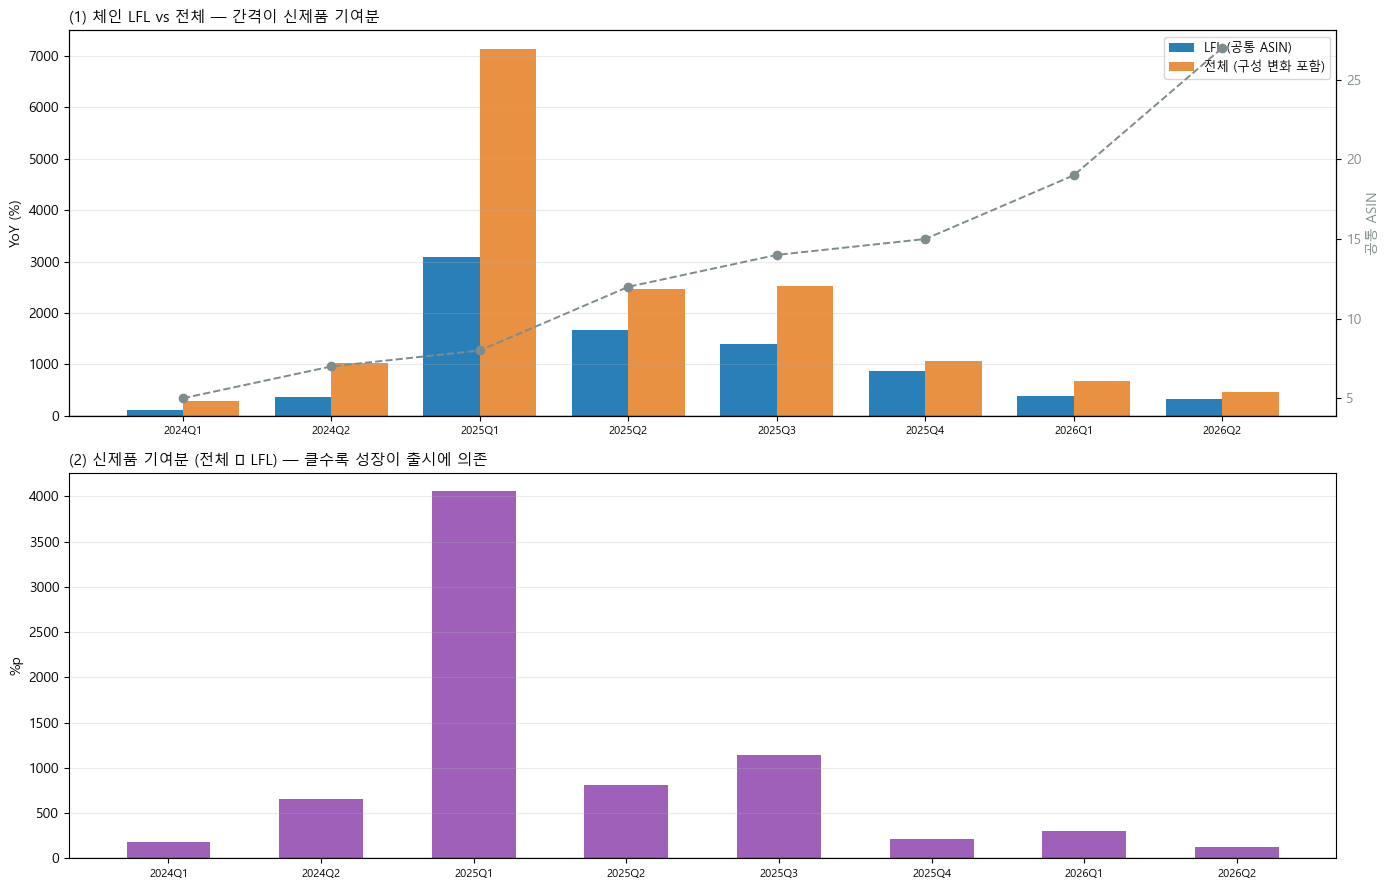

In [14]:
if SHOW_PLOTS and len(lfl):
    import matplotlib.pyplot as plt

    p = lfl.dropna(subset=["lfl_yoy"])
    if len(p):
        labels = [str(q) for q in p.index]
        xs = np.arange(len(p)); w = 0.38

        fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 9))

        ax = axes[0]
        ax.bar(xs - w / 2, p["lfl_yoy"] * 100, w, label="LFL (공통 ASIN)", color="#2980b9")
        ax.bar(xs + w / 2, p["total_yoy"] * 100, w, label="전체 (구성 변화 포함)",
               color="#e67e22", alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel("YoY (%)")
        ax.set_title("(1) 체인 LFL vs 전체 — 간격이 신제품 기여분",
                     fontsize=11, loc="left")
        ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

        ax2 = ax.twinx()
        ax2.plot(xs, p["n_common"], color="#7f8c8d", marker="o",
                 linewidth=1.4, linestyle="--", label="공통 ASIN 수")
        ax2.set_ylabel("공통 ASIN", color="#7f8c8d")
        ax2.tick_params(axis="y", labelcolor="#7f8c8d")

        ax = axes[1]
        ax.bar(xs, p["sku_effect"] * 100, 0.55, color="#8e44ad", alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel("%p")
        ax.set_title("(2) 신제품 기여분 (전체 − LFL) — 클수록 성장이 출시에 의존",
                     fontsize=11, loc="left")
        ax.grid(alpha=0.25, axis="y")

        plt.tight_layout(); plt.show()


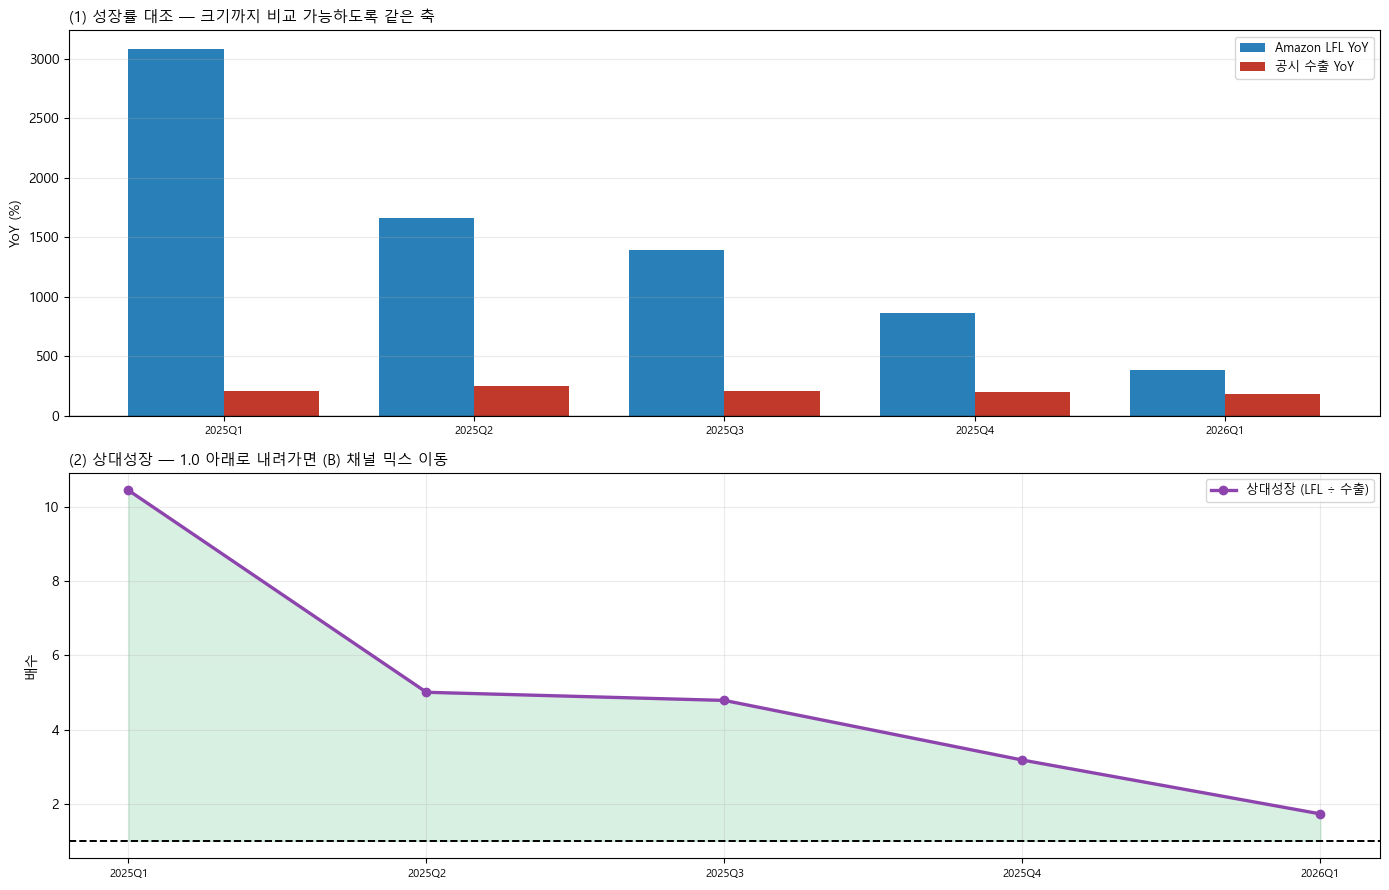

         LFL가속  수출가속 방향   크기비 엄격
2025Q1     NaN   NaN  X   NaN  X
2025Q2 -1423.1  47.3  X  30.1  X
2025Q3  -272.5 -40.8  O   6.7  X
2025Q4  -527.4  -8.4  O  62.8  X
2026Q1  -480.7 -23.8  O  20.2  X

  방향은 O인데 엄격이 X면, 부호만 우연히 맞은 것입니다.


In [15]:
if SHOW_PLOTS and len(rel) >= 2:
    import matplotlib.pyplot as plt

    labels = [str(q) for q in rel.index]
    xs = np.arange(len(rel)); w = 0.38

    fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 9))

    ax = axes[0]
    ax.bar(xs - w / 2, rel["lfl_yoy"] * 100, w, label="Amazon LFL YoY", color="#2980b9")
    ax.bar(xs + w / 2, rel["export_yoy"] * 100, w, label="공시 수출 YoY", color="#c0392b")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("YoY (%)")
    ax.set_title("(1) 성장률 대조 — 크기까지 비교 가능하도록 같은 축",
                 fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

    ax = axes[1]
    ax.plot(xs, rel["rel_lfl"], marker="o", color="#8e44ad", linewidth=2.4,
            label="상대성장 (LFL ÷ 수출)")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.4)
    ax.fill_between(xs, 1.0, rel["rel_lfl"], where=(rel["rel_lfl"] >= 1.0),
                    color="#27ae60", alpha=0.18)
    ax.fill_between(xs, 1.0, rel["rel_lfl"], where=(rel["rel_lfl"] < 1.0),
                    color="#c0392b", alpha=0.18)
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("배수")
    ax.set_title("(2) 상대성장 — 1.0 아래로 내려가면 (B) 채널 믹스 이동",
                 fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()

    chk = pd.DataFrame({
        "LFL가속": (rel["lfl_yoy"].diff() * 100).round(1).values,
        "수출가속": (rel["export_yoy"].diff() * 100).round(1).values,
    }, index=labels)
    chk["방향"] = np.where(np.sign(chk["LFL가속"]) == np.sign(chk["수출가속"]), "O", "X")
    chk["크기비"] = (chk["LFL가속"].abs() / chk["수출가속"].abs()).round(1)
    chk["엄격"] = np.where((chk["방향"] == "O") &
                          (chk["크기비"] <= MAGNITUDE_MAX) &
                          (chk["크기비"] >= 1 / MAGNITUDE_MAX), "O", "X")
    print(chk.to_string())
    print()
    print("  방향은 O인데 엄격이 X면, 부호만 우연히 맞은 것입니다.")


In [16]:
if CUSTOMS_ENABLED and DB_AVAILABLE and CUSTOMS_SQL:
    try:
        ind = pd.read_sql(text(CUSTOMS_SQL), ENGINE)
        ind[CUSTOMS_DATE_COL] = pd.to_datetime(ind[CUSTOMS_DATE_COL])
        ind["q"] = ind[CUSTOMS_DATE_COL].dt.to_period("Q")
        iq = ind.groupby("q")[CUSTOMS_VAL_COL].sum()
        rq = rev.set_index("period")
        industry = pd.DataFrame({"apr_yoy": rq["export_yoy"],
                                 "industry_yoy": iq.pct_change(4)}).dropna()
        industry["alpha_pp"] = (industry["apr_yoy"] - industry["industry_yoy"]) * 100
        print("=" * 66); print("산업 대비 알파 (%p)"); print("=" * 66)
        s = industry.copy()
        for c in ["apr_yoy", "industry_yoy"]:
            s[c] = s[c].map(lambda x: "%.0f%%" % (x * 100))
        s["alpha_pp"] = s["alpha_pp"].map(lambda x: "%+.0f%%p" % x)
        print(s.to_string())
        print("\n  양수 = 산업보다 빠른 성장 (점유율 확대)")
    except Exception as e:
        print("[관세청] 조회 실패:", repr(e)[:200])
else:
    print("[관세청] 비활성. CUSTOMS_ENABLED=True + CUSTOMS_SQL 을 채우십시오.")


[관세청] 비활성. CUSTOMS_ENABLED=True + CUSTOMS_SQL 을 채우십시오.


## 11. 요약

In [17]:
print("=" * 78)
print("APR Amazon 지수 — V5 요약 (체인 LFL)")
print("=" * 78)
print("  앵커 : 분기 %d개 / 수출 YoY %d개"
      % (len(rev), int(rev["export_yoy"].notna().sum())))
if len(daily):
    st = cov_stats(daily)
    print("  패널 : 재보간 limit=%d일 / 톱니 %.3f / 보간 %.0f%%"
          % (REFILL_LIMIT_D, st.get("jag", 0), st.get("ffill", 0) * 100))
    print("  분석 : %s ~ %s" % (ANALYSIS_START.date(), ANALYSIS_END.date()))
if len(lfl):
    ok_lfl = lfl["lfl_yoy"].dropna()
    print("  LFL  : 유효 분기 %d개 / 평균 공통 ASIN %.1f개"
          % (len(ok_lfl), lfl.loc[ok_lfl.index, "n_common"].mean()))
    print("         LFL YoY 중앙 %+.0f%% / 최근 %+.0f%%"
          % (ok_lfl.median() * 100, ok_lfl.iloc[-1] * 100))
if len(rel):
    print("  상대 : 최근 %.2fx (1.0 = 수출과 같은 속도)" % rel["rel_lfl"].iloc[-1])
print()
print("  판정 : %s" % VERDICT)
for w in WHY:
    print("         · %s" % w)
print()
print("  [다음 행동]")
print("   1. 8장 창 민감도에서 LFL YoY 가 현실적이고 관측치가 최대인 창을 고르십시오.")
print("   2. 9장 대기 분기 표를 기록해두십시오. 사전 기록만이 예측력의 증거입니다.")
print("   3. 2026Q2 반기보고서의 누적 수출액을 CUM_EXPORT 에 추가하십시오.")
print("   4. 상대성장이 1.0 아래로 가면 Amazon 단독 추적을 재검토해야 합니다.")
print("=" * 78)


APR Amazon 지수 — V5 요약 (체인 LFL)
  앵커 : 분기 9개 / 수출 YoY 5개
  패널 : 재보간 limit=21일 / 톱니 0.002 / 보간 9%
  분석 : 2023-01-01 ~ 2026-08-03
  LFL  : 유효 분기 8개 / 평균 공통 ASIN 13.4개
         LFL YoY 중앙 +621% / 최근 +331%
  상대 : 최근 1.72x (1.0 = 수출과 같은 속도)

  판정 : 판정 유보
         · 가속 관측치 4개 < 기준 5개

  [다음 행동]
   1. 8장 창 민감도에서 LFL YoY 가 현실적이고 관측치가 최대인 창을 고르십시오.
   2. 9장 대기 분기 표를 기록해두십시오. 사전 기록만이 예측력의 증거입니다.
   3. 2026Q2 반기보고서의 누적 수출액을 CUM_EXPORT 에 추가하십시오.
   4. 상대성장이 1.0 아래로 가면 Amazon 단독 추적을 재검토해야 합니다.


---

## V5가 바꾼 것

| | V4 | V5 |
|---|---|---|
| 지수 | 고정 바스켓(균형패널) | **분기별 체인 LFL** |
| 균형패널 문제 | 4개로 판정 불가 | 개념 자체가 없어짐 |
| 점유율 | 누적곱 (+7286%) | 분기별 상대성장 추세 |
| 일치 판정 | 부호만 | **부호 + 크기비** |
| 미완결 분기 | 그대로 포함 | 커버리지 기준으로 제외 |
| 창 선택 | 임의 | 민감도 표로 판단 |

## 여전한 한계

1. **수출에는 미국 외가 섞여 있다.** 순수 미국 신호가 아니다.
2. **Amazon은 미국 매출의 일부다.** Ulta·TikTok·DTC 미포함.
3. **관측치가 근본적으로 적다.** 분기 데이터의 숙명이며, 종목 수를 늘리는 것 외에
   우회로가 없다. 실리콘투·삼양식품 등으로 확장하면 패널 관측치가 늘어난다.
4. **`ALPHA`는 자유 파라미터다.** 민감도 표에서 흔들리면 신뢰할 수 없다.

---
*V5 · 2026-08 · 짝 노트북: `apr_us_amazon_keepa_v4`, `apr_us_google_trends_v2`*